In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("diabetes.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Input Features:")
print(X.columns.tolist())

print("\nTarget Variable: Outcome")

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

Input Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target Variable: Outcome

Feature Shape: (768, 8)
Target Shape: (768,)


In [6]:
invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Zero values in potentially invalid columns:\n")

for column in invalid_columns:
    print(column, ":", (df[column] == 0).sum())

Zero values in potentially invalid columns:

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


In [7]:
df_clean = df.copy()

for column in invalid_columns:
    df_clean[column] = df_clean[column].replace(0, np.nan)

print("Missing values after replacing invalid zeros:\n")
print(df_clean.isnull().sum())

Missing values after replacing invalid zeros:

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [8]:
for column in invalid_columns:
    df_clean[column] = df_clean[column].fillna(
        df_clean[column].median()
    )

print("Missing values after median imputation:\n")
print(df_clean.isnull().sum())

Missing values after median imputation:

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [9]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

print("Features:")
print(X.columns.tolist())

print("\nTarget Distribution:")
print(y.value_counts())

Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (614, 8)
Testing set: (154, 8)

Training target distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Testing target distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [12]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [13]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("First 20 Predictions:")
print(y_pred_logistic[:20])

First 20 Predictions:
[1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0]


In [14]:
y_prob_logistic = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print("\nFirst 10 predicted probabilities:")
print(y_prob_logistic[:10])


First 10 predicted probabilities:
[0.60971073 0.11835576 0.29346313 0.2508367  0.03320667 0.16852385
 0.4881643  0.92367511 0.08143405 0.8385896 ]


In [15]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Confusion Matrix:")
print(cm_logistic)

Logistic Regression Confusion Matrix:
[[82 18]
 [27 27]]


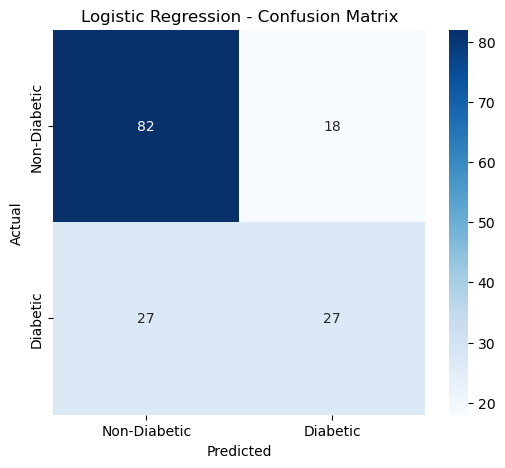

In [16]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [17]:
accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

precision_logistic = precision_score(
    y_test,
    y_pred_logistic
)

recall_logistic = recall_score(
    y_test,
    y_pred_logistic
)

f1_logistic = f1_score(
    y_test,
    y_pred_logistic
)

auc_logistic = roc_auc_score(
    y_test,
    y_prob_logistic
)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", round(accuracy_logistic, 4))
print("Precision:", round(precision_logistic, 4))
print("Recall   :", round(recall_logistic, 4))
print("F1-Score :", round(f1_logistic, 4))
print("ROC-AUC  :", round(auc_logistic, 4))

Logistic Regression Performance
--------------------------------
Accuracy : 0.7078
Precision: 0.6
Recall   : 0.5
F1-Score : 0.5455
ROC-AUC  : 0.813


In [18]:
print("Logistic Regression Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["Non-Diabetic", "Diabetic"]
    )
)

Logistic Regression Classification Report:

              precision    recall  f1-score   support

Non-Diabetic       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [19]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

print("k-NN model trained successfully!")

k-NN model trained successfully!


In [20]:
y_pred_knn = knn_model.predict(X_test_scaled)

y_prob_knn = knn_model.predict_proba(
    X_test_scaled
)[:, 1]

print("First 20 k-NN Predictions:")
print(y_pred_knn[:20])

First 20 k-NN Predictions:
[1 0 0 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0]


In [21]:
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

print("k-NN Confusion Matrix:")
print(cm_knn)

k-NN Confusion Matrix:
[[83 17]
 [21 33]]


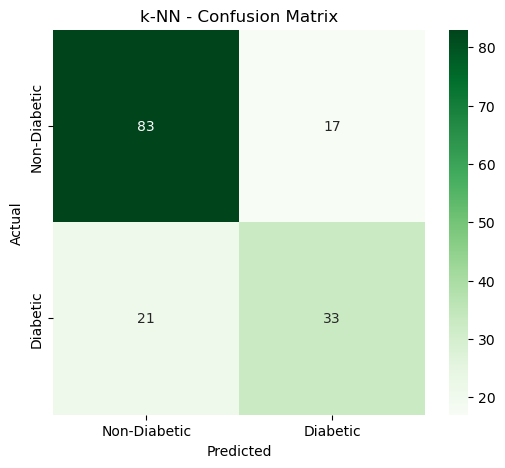

In [22]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("k-NN - Confusion Matrix")

plt.show()

In [23]:
accuracy_knn = accuracy_score(
    y_test,
    y_pred_knn
)

precision_knn = precision_score(
    y_test,
    y_pred_knn
)

recall_knn = recall_score(
    y_test,
    y_pred_knn
)

f1_knn = f1_score(
    y_test,
    y_pred_knn
)

auc_knn = roc_auc_score(
    y_test,
    y_prob_knn
)

print("k-NN Performance")
print("----------------")
print("Accuracy :", round(accuracy_knn, 4))
print("Precision:", round(precision_knn, 4))
print("Recall   :", round(recall_knn, 4))
print("F1-Score :", round(f1_knn, 4))
print("ROC-AUC  :", round(auc_knn, 4))

k-NN Performance
----------------
Accuracy : 0.7532
Precision: 0.66
Recall   : 0.6111
F1-Score : 0.6346
ROC-AUC  : 0.7886


In [24]:
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [25]:
y_pred_tree = tree_model.predict(X_test)

y_prob_tree = tree_model.predict_proba(
    X_test
)[:, 1]

print("First 20 Decision Tree Predictions:")
print(y_pred_tree[:20])

First 20 Decision Tree Predictions:
[1 0 0 1 0 0 0 1 0 1 1 1 0 0 0 1 1 0 1 0]


In [26]:
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

print("Decision Tree Confusion Matrix:")
print(cm_tree)

Decision Tree Confusion Matrix:
[[78 22]
 [15 39]]


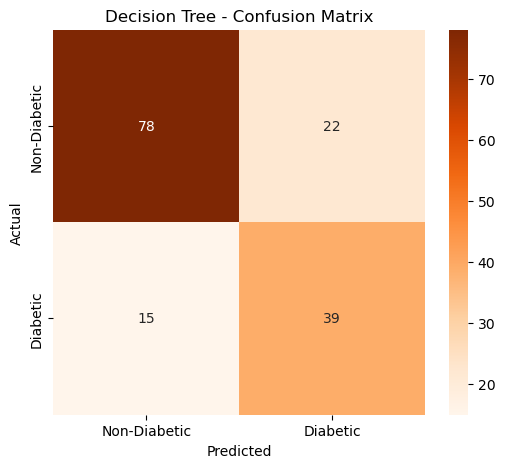

In [27]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")

plt.show()

In [28]:
accuracy_tree = accuracy_score(
    y_test,
    y_pred_tree
)

precision_tree = precision_score(
    y_test,
    y_pred_tree
)

recall_tree = recall_score(
    y_test,
    y_pred_tree
)

f1_tree = f1_score(
    y_test,
    y_pred_tree
)

auc_tree = roc_auc_score(
    y_test,
    y_prob_tree
)

print("Decision Tree Performance")
print("-------------------------")
print("Accuracy :", round(accuracy_tree, 4))
print("Precision:", round(precision_tree, 4))
print("Recall   :", round(recall_tree, 4))
print("F1-Score :", round(f1_tree, 4))
print("ROC-AUC  :", round(auc_tree, 4))

Decision Tree Performance
-------------------------
Accuracy : 0.7597
Precision: 0.6393
Recall   : 0.7222
F1-Score : 0.6783
ROC-AUC  : 0.7622


In [29]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "k-NN",
        "Decision Tree"
    ],
    
    "Accuracy": [
        accuracy_logistic,
        accuracy_knn,
        accuracy_tree
    ],
    
    "Precision": [
        precision_logistic,
        precision_knn,
        precision_tree
    ],
    
    "Recall": [
        recall_logistic,
        recall_knn,
        recall_tree
    ],
    
    "F1-Score": [
        f1_logistic,
        f1_knn,
        f1_tree
    ],
    
    "ROC-AUC": [
        auc_logistic,
        auc_knn,
        auc_tree
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7078,0.6000,0.5000,0.5455,0.8130
1,k-NN,0.7532,0.6600,0.6111,0.6346,0.7886
2,Decision Tree,0.7597,0.6393,0.7222,0.6783,0.7622


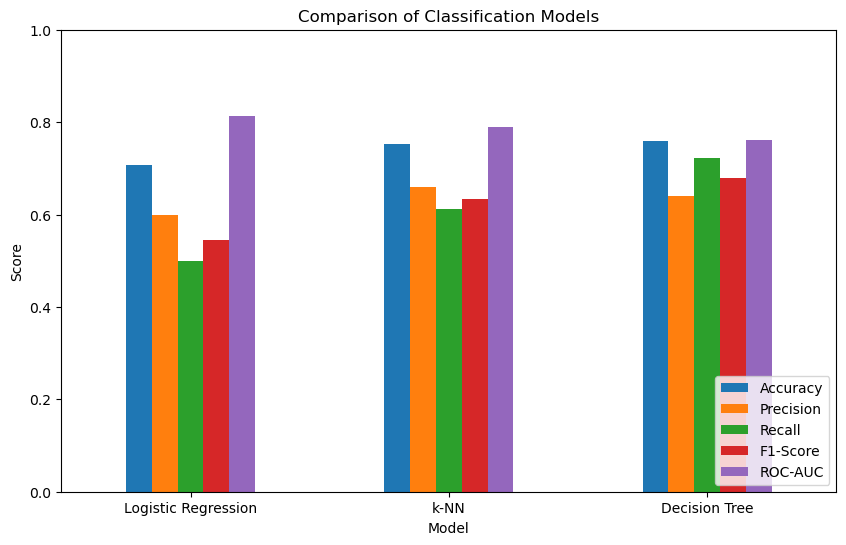

In [30]:
results_plot = results.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Classification Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

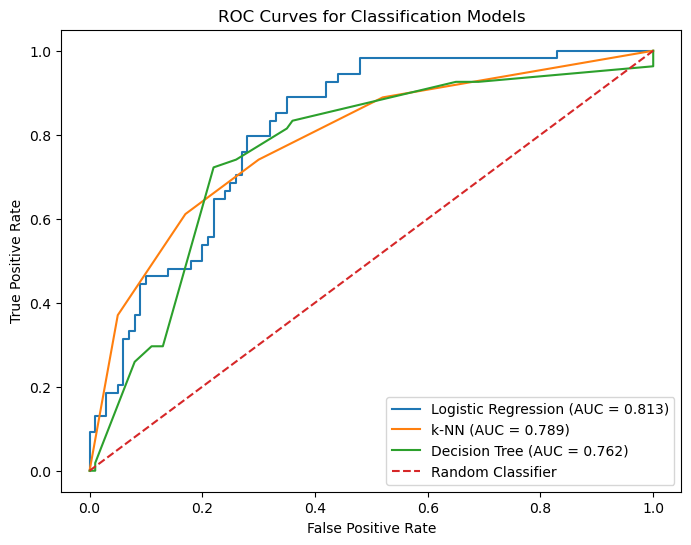

In [31]:
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_prob_logistic
)

fpr_knn, tpr_knn, _ = roc_curve(
    y_test,
    y_prob_knn
)

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    y_prob_tree
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {auc_logistic:.3f})"
)

plt.plot(
    fpr_knn,
    tpr_knn,
    label=f"k-NN (AUC = {auc_knn:.3f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {auc_tree:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Classification Models")
plt.legend()

plt.show()